In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split


In [26]:
df= pd.read_csv('./CSVs/titanic_toy.csv')

In [27]:
df

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0
...,...,...,...,...
886,27.0,13.0000,0,0
887,19.0,30.0000,0,1
888,NaN,23.4500,3,0
889,26.0,NaN,0,1


In [28]:
df.describe()

,Age,Fare,Family,Survived
count,714.000000,846.000000,891.000000,891.000000
mean,29.699118,32.279338,0.904602,0.383838
std,14.526497,50.305796,1.613459,0.486592
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,7.895800,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,38.000000,31.206250,1.000000,1.000000
max,80.000000,512.329200,10.000000,1.000000


In [29]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [30]:
X=df.drop('Survived',axis=1)

In [31]:
Y=df.Survived

In [32]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [33]:
x_train.shape, x_test.shape

((712, 3), (179, 3))

In [36]:
df['age_mean']=df.Age.fillna(np.mean(df.Age))
df['age_median']=df.Age.fillna(df.Age.median())

In [37]:
df.sample(10)

,Age,Fare,Family,Survived,age_mean,age_median
832,NaN,7.2292,0,0,29.699118,28.00
117,29.00,21.0000,1,0,29.000000,29.00
694,60.00,26.5500,0,0,60.000000,60.00
469,0.75,NaN,3,1,0.750000,0.75
425,NaN,7.2500,0,0,29.699118,28.00
727,NaN,7.7375,0,1,29.699118,28.00
240,NaN,14.4542,1,0,29.699118,28.00
389,17.00,12.0000,0,1,17.000000,17.00
403,28.00,15.8500,1,0,28.000000,28.00
696,44.00,8.0500,0,0,44.000000,44.00


In [41]:
df['fare_mean']=df.Fare.fillna(np.mean(df.Fare))
df['fare_median']=df.Fare.fillna(df.Fare.median())

In [47]:
df.sample(10)

,Age,Fare,Family,Survived,age_mean,age_median,fare_mean,fare_median
291,19.0,91.0792,1,1,19.000000,19.0,91.079200,91.0792
132,47.0,14.5000,1,0,47.000000,47.0,14.500000,14.5000
79,30.0,12.4750,0,1,30.000000,30.0,12.475000,12.4750
33,66.0,10.5000,0,0,66.000000,66.0,10.500000,10.5000
698,49.0,NaN,2,0,49.000000,49.0,32.279338,14.4542
425,NaN,7.2500,0,0,29.699118,28.0,7.250000,7.2500
626,57.0,12.3500,0,0,57.000000,57.0,12.350000,12.3500
826,NaN,56.4958,0,0,29.699118,28.0,56.495800,56.4958
136,19.0,26.2833,2,1,19.000000,19.0,26.283300,26.2833
292,36.0,12.8750,0,0,36.000000,36.0,12.875000,12.8750


In [48]:
df.var()

Age             211.019125
Fare           2530.673077
Family            2.603248
Survived          0.236772
age_mean        169.052400
age_median      169.512498
fare_mean      2402.717697
fare_median    2417.971600
dtype: float64

In [49]:
df.corr()

,Age,Fare,Family,Survived,age_mean,age_median,fare_mean,fare_median
Age,1.000000,0.099481,-0.301914,-0.077221,1.000000,1.000000,0.097273,0.096203
Fare,0.099481,1.000000,0.212626,0.263920,0.094681,0.099626,1.000000,1.000000
Family,-0.301914,0.212626,1.000000,0.016639,-0.248512,-0.245619,0.209609,0.209378
Survived,-0.077221,0.263920,0.016639,1.000000,-0.069809,-0.064910,0.256445,0.251678
age_mean,1.000000,0.094681,-0.248512,-0.069809,1.000000,0.998642,0.092676,0.091718
age_median,1.000000,0.099626,-0.245619,-0.064910,0.998642,1.000000,0.097513,0.096384
fare_mean,0.097273,1.000000,0.209609,0.256445,0.092676,0.097513,1.000000,0.996841
fare_median,0.096203,1.000000,0.209378,0.251678,0.091718,0.096384,0.996841,1.000000


<Axes: ylabel='Density'>

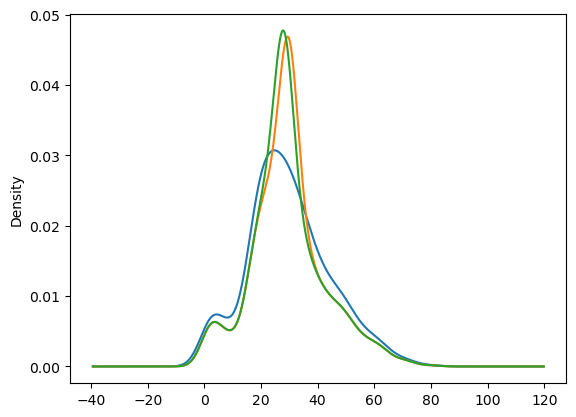

In [56]:
fig=plt.figure()
ax=fig.add_subplot(111)
df.Age.plot(kind='kde',ax=ax)
df.age_mean.plot(kind='kde',ax=ax)
df.age_median.plot(kind='kde',ax=ax)

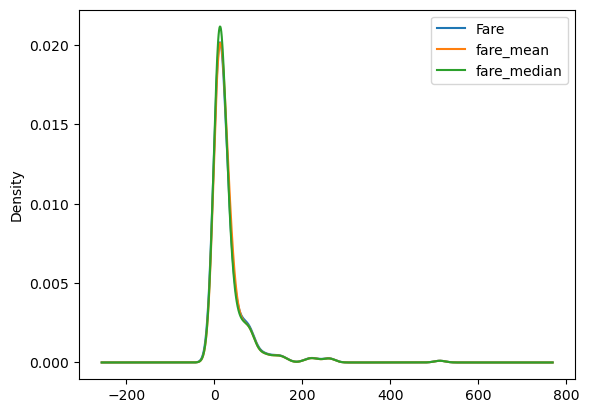

In [58]:
fig=plt.figure()
ax=fig.add_subplot(111)
df.Fare.plot(kind='kde',ax=ax)
df.fare_mean.plot(kind='kde',ax=ax)
df.fare_median.plot(kind='kde',ax=ax)
lines,labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc="best")

<Axes: >

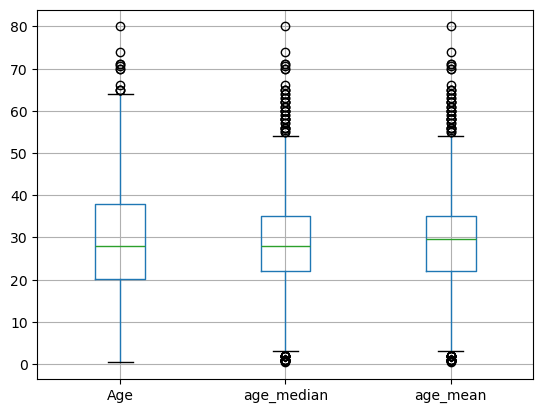

In [59]:
df[['Age','age_median','age_mean']].boxplot()

<Axes: >

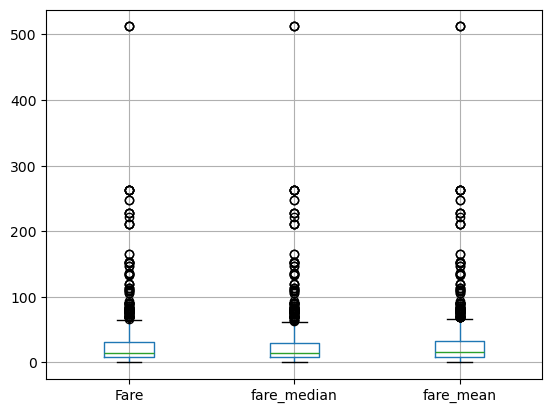

In [61]:
df[['Fare','fare_median','fare_mean']].boxplot()